# Steam Game Similarity Graph - Community Detection
**Course:** Graph Algorithms | **Instructor:** Dr. Avner Friel

**Students:** Yanir Karpis,Chen Brown,Shaked Rosenberg

**Research Question:** Do communities that emerge naturally from player behavior align with Steam's official genre classifications?

**Pipeline:** Install -> Load data -> Genre matching -> Build graph -> Community detection -> Centrality -> Visualize -> NMI

In [ ]:
# Install all required packages
# python-louvain : Louvain community detection algorithm
# thefuzz        : fuzzy string matching (for genre lookup)
# networkx       : graph construction and graph algorithms
# scikit-learn   : NMI evaluation metric
!pip install -q gdown python-louvain thefuzz[speedup] networkx matplotlib scikit-learn tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 34.6 MB/s eta 0:00:00


In [ ]:
# Import all libraries used throughout the notebook
import pandas as pd
import json
import zipfile
import os
import re
import gdown
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import community as community_louvain
from thefuzz import process as fuzz_process
from collections import defaultdict, Counter
from sklearn.metrics import normalized_mutual_info_score
from sklearn.preprocessing import LabelEncoder
from tqdm.auto import tqdm

print('All imports successful')

All imports successful


In [ ]:
# Download the dataset from Google Drive
# Contains: steam-200k.csv (user play behavior) and games.json (game genres)
DATA_DIR = '/content/steam dataset project'

folder_id = '1CPsdP4JfE8WzDt2Rj5gOf8S5fQKXPcs5'
gdown.download_folder(
    f'https://drive.google.com/drive/folders/{folder_id}',
    quiet=False,
    use_cookies=False
)

# Extract zip files inside the downloaded folder
for zname in ['steam dataset.zip', 'steam dataset tags 2.zip']:
    zpath = f'{DATA_DIR}/{zname}'
    if os.path.exists(zpath):
        with zipfile.ZipFile(zpath, 'r') as z:
            z.extractall(DATA_DIR)
        print(f'Extracted: {zname}')

Retrieving folder contents


Processing file 1H54_VLWXxTF4xq7gUsA_6OEZGPWdx-m8 steam dataset tags 2.zip
Processing file 1e_vrwaJsD8wkl3WSrCgnNm_eau_OA1p1 steam dataset.zip


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1H54_VLWXxTF4xq7gUsA_6OEZGPWdx-m8
From (redirected): https://drive.google.com/uc?id=1H54_VLWXxTF4xq7gUsA_6OEZGPWdx-m8&confirm=t&uuid=fe367423-fe52-4d02-bcd3-32890b0b2186
To: /content/steam dataset project/steam dataset tags 2.zip
100%|██████████| 283M/283M [00:04<00:00, 69.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=1e_vrwaJsD8wkl3WSrCgnNm_eau_OA1p1
To: /content/steam dataset project/steam dataset.zip
100%|██████████| 1.53M/1.53M [00:00<00:00, 12.1MB/s]
Download completed


Extracted: steam dataset.zip
Extracted: steam dataset tags 2.zip


In [ ]:
# Load the main Steam dataset
# Each row = one user-game interaction: user_id, game_title, behavior (play/purchase), hours
df = pd.read_csv(
    f'{DATA_DIR}/steam-200k.csv',
    header=None,
    names=['user_id', 'game_title', 'behavior', 'hours', 'extra']
)

# Keep only 'play' rows (ignore purchase-only records)
df_play = df[df['behavior'] == 'play'].copy()

# If a user has multiple entries for the same game, keep the highest hours
df_play = df_play.sort_values('hours', ascending=False)
df_play = df_play.drop_duplicates(subset=['user_id', 'game_title'], keep='first')

print(f'Play rows    : {len(df_play):,}')
print(f'Unique users : {df_play["user_id"].nunique():,}')
print(f'Unique games : {df_play["game_title"].nunique():,}')
df_play.head()

Play rows    : 70,477
Unique users : 11,350
Unique games : 3,600


,user_id,game_title,behavior,hours,extra
123726,73017395,Sid Meier's Civilization V,play,11754.0,0
112643,100630947,Dota 2,play,10442.0,0
187005,153382649,Team Fortress 2,play,9640.0,0
165596,130882834,Dota 2,play,7765.0,0
183461,52567955,Dota 2,play,6964.0,0


In [ ]:
import pandas as pd
import json
import os

# Load the tag database from games.json.
# Strategy: use the highest-voted community tag as the primary label.
# We block mode/platform and aesthetic tags, then consolidate the remaining
# granular tags into broad genre buckets via TAG_CONSOLIDATION.
# Fall back to genres[0] if a game has no usable tags.

META_TAGS = {
    # Play mode / multiplayer format
    "Singleplayer", "Multiplayer", "Co-op", "Online Co-Op", "Local Co-Op",
    "PvP", "PvE", "Tutorial", "Family Friendly", "2D", "3D",
    "First-Person", "Third Person", "Early Access",
    "Free to Play", "Free To Play",
    "Indie",
    "VR",
    # Aesthetic / tone descriptors
    "Comedy", "Funny", "Cute", "Colorful", "Stylized", "Anime",
    "Atmospheric", "Dark", "Relaxing", "Difficult", "Pixel Graphics",
    "Retro", "Great Soundtrack", "Short", "Linear", "Violent", "Mature",
    "Sexual Content", "Nudity", "Gore",
    # Non-game software
    "Utilities", "Software", "Game Development", "Education",
    "Audio Production", "Video Production", "Animation & Modeling",
    "Photo Editing", "Documentary", "Design & Illustration",
}

# Consolidation map: granular tags → broad genre buckets
TAG_CONSOLIDATION = {
    # → Shooter
    "FPS": "Shooter", "Hero Shooter": "Shooter", "Military": "Shooter",
    "Tactical": "Shooter", "Battle Royale": "Shooter",
    "Looter Shooter": "Shooter", "Shoot 'Em Up": "Shooter",
    # → RPG
    "Action RPG": "RPG", "JRPG": "RPG", "Loot": "RPG",
    "Dark Fantasy": "RPG", "MMORPG": "RPG", "Massively Multiplayer": "RPG",
    # → Action
    "Beat 'em up": "Action", "Action-Adventure": "Action",
    "Cyberpunk": "Action", "Medieval": "Action",
    "Hack and Slash": "Action", "Action Roguelike": "Action",
    "Rogue-like": "Action", "Roguelike": "Action",
    "Heist": "Action", "Stealth": "Action",
    "Dinosaurs": "Action",
    # → Strategy
    "Turn-Based Strategy": "Strategy", "Tower Defense": "Strategy",
    "Warhammer 40K": "Strategy", "4X": "Strategy",
    "Real Time Tactics": "Strategy", "Grand Strategy": "Strategy",
    "RTS": "Strategy", "City Builder": "Strategy",
    # → Survival
    "Zombies": "Survival", "Open World Survival Craft": "Survival",
    "Post-apocalyptic": "Survival",
    # → Platformer
    "Precision Platformer": "Platformer", "Puzzle-Platformer": "Platformer",
    "2D Platformer": "Platformer", "Side Scroller": "Platformer",
    "3D Platformer": "Platformer",
    # → Adventure
    "Narration": "Adventure", "Exploration": "Adventure",
    "Visual Novel": "Adventure", "Story Rich": "Adventure",
    # → Simulation
    "Driving": "Simulation", "Football (Soccer)": "Simulation",
    "Racing": "Simulation", "Sports": "Simulation",
    "Trains": "Simulation", "Flight": "Simulation",
    "Space": "Simulation",
    # → Horror
    "Psychological Horror": "Horror",
    # → Casual
    "Clicker": "Casual", "Hidden Object": "Casual", "Arcade": "Casual",
    # → Puzzle
    "Match 3": "Puzzle",
}

with open(f"{DATA_DIR}/games.json", "r") as f:
    raw_json = json.load(f)

games_list = []
for app_id, info in raw_json.items():
    name   = info.get("name", "")
    tags   = info.get("tags",   {})
    genres = info.get("genres", [])

    if not name:
        continue

    # Pick the highest-voted tag that is not a meta/aesthetic tag
    primary = None
    if isinstance(tags, dict) and tags:
        for tag in sorted(tags, key=tags.get, reverse=True):
            if tag not in META_TAGS:
                primary = tag
                break

    # Fall back to genres[0] if no usable tag found
    if primary is None and genres:
        primary = genres[0]

    if primary:
        primary = TAG_CONSOLIDATION.get(primary, primary)
        games_list.append({"name": name, "genre": primary})

df_tags = pd.DataFrame(games_list)
print(f"Tag database: {df_tags['name'].nunique():,} unique games  ({len(df_tags):,} rows)")
print(f"Top tags:\n{df_tags['genre'].value_counts().head(20)}")

Tag database: 113,182 unique games  (114,304 rows)
Top tags:
genre
Action                       28415
Casual                       21912
Adventure                    18975
Simulation                    7376
Strategy                      5981
RPG                           5317
Indie                         2887
Platformer                    2568
Horror                        2346
Puzzle                        1859
Shooter                       1311
Survival                       729
Free To Play                   397
Choose Your Own Adventure      301
Bullet Hell                    295
Metroidvania                   278
Turn-Based Tactics             275
Utilities                      252
Arena Shooter                  250
Survival Horror                243
Name: count, dtype: int64


In [ ]:
# Match game titles between the two datasets to assign a genre/tag label.
# Problem: titles differ slightly in punctuation, spacing, capitalization.
# Solution: three-pass matching
#   Pass 1 - exact match after cleaning (lowercase + strip punctuation)
#   Pass 2 - fuzzy match on the tag-based lookup (score >= 90, length ratio >= 0.4)
#   Pass 3 - genre-only fallback for still-unmatched games (recovers dropped games)

def clean_name(name):
    name = str(name).lower().strip()
    name = re.sub(r"[^\w\s]", "", name)
    name = re.sub(r"\s+", " ", name)
    return name

# Build clean-name -> tag label lookup (majority vote handles duplicate cleaned names)
df_tags["name_clean"] = df_tags["name"].apply(clean_name)
tag_lookup = (
    df_tags.groupby("name_clean")["genre"]
           .agg(lambda x: x.value_counts().index[0])
)

# Pass 1: exact match after cleaning
df_play["name_clean"] = df_play["game_title"].apply(clean_name)
df_play["genre"] = df_play["name_clean"].map(tag_lookup)

unmatched_titles = df_play[df_play["genre"].isna()]["game_title"].drop_duplicates().tolist()
print(f"Pass 1 (exact)  -> matched: {df_play['game_title'][df_play['genre'].notna()].nunique():,}  unmatched: {len(unmatched_titles):,}")

# Pass 2: fuzzy match on tag-based lookup
FUZZY_CUTOFF  = 90
MIN_LEN_RATIO = 0.4  # rejects short garbage matches like "eon" -> "napoleon total war"
MIN_NAME_LEN  = 4

tag_name_list = tag_lookup.index.tolist()
fuzzy_map = {}

for title in tqdm(unmatched_titles, desc="Pass 2 (fuzzy tag)"):
    q = clean_name(title)
    if len(q) < MIN_NAME_LEN:
        continue
    result = fuzz_process.extractOne(q, tag_name_list, score_cutoff=FUZZY_CUTOFF)
    if result:
        matched_name = result[0]
        len_ratio = min(len(q), len(matched_name)) / max(len(q), len(matched_name))
        if len_ratio >= MIN_LEN_RATIO:
            fuzzy_map[title] = tag_lookup.get(matched_name)

df_play["genre"] = df_play.apply(
    lambda r: r["genre"] if pd.notna(r["genre"]) else fuzzy_map.get(r["game_title"]),
    axis=1
)

still_unmatched = df_play[df_play["genre"].isna()]["game_title"].drop_duplicates().tolist()
print(f"Pass 2 (fuzzy)  -> matched: {df_play['game_title'][df_play['genre'].notna()].nunique():,}  unmatched: {len(still_unmatched):,}")

# Pass 3: genre-only fallback for games still without a label
# Uses the raw genres field from games.json as a last resort.
# This recovers games that failed fuzzy tag matching but have a valid genre entry.
genre_fallback_lookup = {}
for app_id, info in raw_json.items():
    name   = info.get("name", "")
    genres = info.get("genres", [])
    if name and genres:
        cn = clean_name(name)
        if cn not in genre_fallback_lookup:
            genre_fallback_lookup[cn] = genres[0]

genre_fallback_names = list(genre_fallback_lookup.keys())
fallback_map = {}

for title in tqdm(still_unmatched, desc="Pass 3 (genre fallback)"):
    q = clean_name(title)
    if len(q) < MIN_NAME_LEN:
        continue
    if q in genre_fallback_lookup:
        fallback_map[title] = genre_fallback_lookup[q]
        continue
    result = fuzz_process.extractOne(q, genre_fallback_names, score_cutoff=FUZZY_CUTOFF)
    if result:
        matched_name = result[0]
        len_ratio = min(len(q), len(matched_name)) / max(len(q), len(matched_name))
        if len_ratio >= MIN_LEN_RATIO:
            fallback_map[title] = genre_fallback_lookup[matched_name]

df_play["genre"] = df_play.apply(
    lambda r: r["genre"] if pd.notna(r["genre"]) else fallback_map.get(r["game_title"]),
    axis=1
)

matched = df_play["game_title"][df_play["genre"].notna()].nunique()
total   = df_play["game_title"].nunique()
print(f"Pass 3 (fallback)-> matched: {matched:,} / {total:,}  ({matched/total*100:.1f}%)")
print(f"\nTop labels in dataset:\n{df_play['genre'].value_counts().head(20)}")

print(f"\nFuzzy tag matches: {len(fuzzy_map)}  |  Genre fallback matches: {len(fallback_map)}")
print(f"\n{'Original title':<45} {'Matched title':<45} {'Score':>5}  Label")
print("-" * 110)
for orig in list(fuzzy_map.keys())[:20]:
    q    = clean_name(orig)
    best = fuzz_process.extractOne(q, tag_name_list)
    print(f"{orig:<45} {best[0] if best else 'N/A':<45} {best[1] if best else 0:>5}  {fuzzy_map[orig]}")

Pass 1 (exact)  -> matched: 2,509  unmatched: 1,091


Pass 2 (fuzzy tag):   0%|          | 0/1091 [00:00<?, ?it/s]

Pass 2 (fuzzy)  -> matched: 2,926  unmatched: 674


Pass 3 (genre fallback):   0%|          | 0/674 [00:00<?, ?it/s]

Pass 3 (fallback)-> matched: 3,007 / 3,600  (83.5%)

Top labels in dataset:
genre
Action           12633
Shooter           7943
Survival          5808
Strategy          5576
MOBA              5040
RPG               4762
Simulation        3815
Open World        3714
Casual            1787
Adventure         1648
Puzzle            1421
Platformer        1113
Horror             994
Sandbox            747
Fighting           381
Card Game          167
Point & Click      156
Superhero          154
LEGO               148
Management         143
Name: count, dtype: int64

Fuzzy tag matches: 417  |  Genre fallback matches: 81

Original title                                Matched title                                 Score  Label
--------------------------------------------------------------------------------------------------------------
FINAL FANTASY XIV A Realm Reborn              final fantasy                                    90  RPG
Football Manager 2014                         football ma

In [ ]:
# Build the game-similarity graph
# Node  = a game (only games that have a known genre)
# Edge  = two games share at least MIN_SHARED_PLAYERS common players
# Weight = Jaccard similarity: shared / (players_A + players_B - shared)
#          Raw co-play count inflates hub-game edges — TF2 with 9,600 players
#          will co-occur with almost every game by chance. Jaccard normalizes
#          for popularity: 25 shared players out of 30 total is a much stronger
#          signal than 25 shared out of 9,000.

MIN_SHARED_PLAYERS = 25

# Only use games that have a genre label
df_g = df_play[df_play['genre'].notna()].copy()

# Total unique players per game — denominator for Jaccard
game_player_counts = df_g.groupby('game_title')['user_id'].nunique()

# Group by user: get the set of games each user played
user_games = df_g.groupby('user_id')['game_title'].apply(set)

# Count shared players for every pair of games
pair_counts = defaultdict(int)
for games in user_games:
    games = list(games)
    for i in range(len(games)):
        for j in range(i + 1, len(games)):
            pair = (min(games[i], games[j]), max(games[i], games[j]))
            pair_counts[pair] += 1

print(f'Total co-play pairs found: {len(pair_counts):,}')

# Create the graph and add nodes with genre attribute
G = nx.Graph()
game_genre = df_g[['game_title','genre']].drop_duplicates('game_title').set_index('game_title')['genre']
for game, genre in game_genre.items():
    G.add_node(game, genre=genre)

# Add edges with Jaccard similarity as weight
for (g1, g2), shared in pair_counts.items():
    if shared >= MIN_SHARED_PLAYERS and G.has_node(g1) and G.has_node(g2):
        a = game_player_counts.get(g1, shared)
        b = game_player_counts.get(g2, shared)
        jaccard = shared / (a + b - shared)
        G.add_edge(g1, g2, weight=jaccard)

# Keep only the largest connected component
lcc = max(nx.connected_components(G), key=len)
G = G.subgraph(lcc).copy()

print(f'Graph: {G.number_of_nodes():,} nodes  |  {G.number_of_edges():,} edges')
print(f'Avg degree: {sum(d for _, d in G.degree()) / G.number_of_nodes():.1f}')

Total co-play pairs found: 636,790
Graph: 333 nodes  |  4,617 edges
Avg degree: 27.7


In [ ]:
import time
from community.community_louvain import best_partition, modularity

# Community Detection - Louvain Algorithm
# Louvain maximizes modularity: it finds groups where games are more connected
# to each other than to the rest of the graph.
# resolution > 1.0 prefers smaller, more granular communities (default = 1.0).
# We use resolution=1.5 to break apart the large merged blobs.

t0 = time.time()
louvain_partition = best_partition(G, weight='weight', random_state=42, resolution=1.5)
louvain_time = time.time() - t0

nx.set_node_attributes(G, louvain_partition, 'louvain')
n_communities = len(set(louvain_partition.values()))
louvain_mod = modularity(louvain_partition, G, weight='weight')

print(f'Louvain found {n_communities} communities in {louvain_time:.2f}s')
print(f'Modularity score: {louvain_mod:.4f}')
print()

sizes = Counter(louvain_partition.values())
for cid, size in sorted(sizes.items()):
    print(f'  Community {cid}: {size} games')

Louvain found 16 communities in 0.06s
Modularity score: 0.1769

  Community 0: 92 games
  Community 1: 14 games
  Community 2: 23 games
  Community 3: 25 games
  Community 4: 8 games
  Community 5: 9 games
  Community 6: 14 games
  Community 7: 16 games
  Community 8: 11 games
  Community 9: 9 games
  Community 10: 10 games
  Community 11: 5 games
  Community 12: 22 games
  Community 13: 23 games
  Community 14: 11 games
  Community 15: 41 games


In [ ]:
# Community Detection - Girvan-Newman Algorithm
# Girvan-Newman repeatedly removes the edge with the highest betweenness
# centrality, splitting the graph into progressively smaller communities.
#
# Correct usage: iterate through ALL splits and keep the partition with the
# highest modularity — NOT stopping at an arbitrary fixed count.
# The previous approach forced 16 communities to match Louvain, which gave
# modularity ≈ 0 because the chosen split was not the natural optimum.

from networkx.algorithms.community import girvan_newman
from community.community_louvain import modularity
import itertools

MAX_COMMUNITIES = 30  # search up to this many communities for the best modularity

print(f'Running Girvan-Newman (searching up to {MAX_COMMUNITIES} communities for best modularity)...')
print('NOTE: Girvan-Newman is O(m^2 * n) — this may take several minutes on a dense graph.')

t0 = time.time()
gn_gen = girvan_newman(G)

best_gn_partition = None
best_gn_mod       = -float('inf')
best_gn_n         = 0

for communities in itertools.islice(gn_gen, MAX_COMMUNITIES - 1):
    part = {node: cid for cid, s in enumerate(communities) for node in s}
    mod  = modularity(part, G, weight='weight')
    if mod > best_gn_mod:
        best_gn_mod       = mod
        best_gn_partition = part
        best_gn_n         = len(communities)

gn_time = time.time() - t0

nx.set_node_attributes(G, best_gn_partition, 'girvan_newman')

print(f'Girvan-Newman done in {gn_time:.1f}s')
print(f'Best partition: {best_gn_n} communities  |  Modularity: {best_gn_mod:.4f}')
print(f'  (Louvain for comparison: {n_communities} communities  |  Modularity: {louvain_mod:.4f})')
print()
sizes = Counter(best_gn_partition.values())
for cid, size in sorted(sizes.items()):
    print(f'  Community {cid}: {size} games')

Running Girvan-Newman (searching up to 30 communities for best modularity)...
NOTE: Girvan-Newman is O(m^2 * n) — this may take several minutes on a dense graph.
Girvan-Newman done in 21.9s
Best partition: 2 communities  |  Modularity: -0.0000
  (Louvain for comparison: 16 communities  |  Modularity: 0.1769)

  Community 0: 332 games
  Community 1: 1 games


In [ ]:
# Centrality Analysis
# PageRank    : measures how 'important' a game is - games played alongside many
#               other popular games score higher
# Betweenness : measures how often a game sits on the shortest path between two
#               other games - high betweenness = bridge between communities
#
# NOTE: betweenness is computed WITHOUT edge weights on purpose.
# nx.betweenness_centrality(weight=...) treats weight as *distance* (cost),
# so passing shared-player counts would make popular connections look *farther*
# apart - the opposite of what we want. Topology alone captures bridging correctly.

print('Computing PageRank...')
pagerank = nx.pagerank(G, weight='weight')

print('Computing Betweenness Centrality...')
betweenness = nx.betweenness_centrality(G, normalized=True)   # unweighted - weight as distance is backwards here

# Store as node attributes
nx.set_node_attributes(G, pagerank,    'pagerank')
nx.set_node_attributes(G, betweenness, 'betweenness')

# Build a summary dataframe for easy inspection
centrality_df = pd.DataFrame([
    {
        'game'       : n,
        'genre'      : G.nodes[n]['genre'],
        'community'  : louvain_partition[n],
        'pagerank'   : round(pagerank[n], 6),
        'betweenness': round(betweenness[n], 6)
    }
    for n in G.nodes
])

print('\nTop 15 games by PageRank:')
print(centrality_df.sort_values('pagerank', ascending=False).head(15).to_string(index=False))

print('\nTop 15 games by Betweenness Centrality:')
print(centrality_df.sort_values('betweenness', ascending=False).head(15).to_string(index=False))

Computing PageRank...
Computing Betweenness Centrality...

Top 15 games by PageRank:
                           game      genre  community  pagerank  betweenness
     The Elder Scrolls V Skyrim Open World         15  0.026751     0.122195
                  Left 4 Dead 2   Survival         10  0.023315     0.083276
                Team Fortress 2    Shooter          0  0.022090     0.285045
                       Portal 2     Puzzle          5  0.021075     0.037352
                  Borderlands 2        RPG         14  0.020940     0.025750
                       Terraria   Survival          8  0.018500     0.022379
                    Garry's Mod    Sandbox          0  0.017436     0.029167
Counter-Strike Global Offensive     Action          0  0.016214     0.078470
     Sid Meier's Civilization V   Strategy         15  0.014470     0.025668
                       PAYDAY 2     Action          3  0.014350     0.010137
                         Portal     Puzzle         12  0.013866     

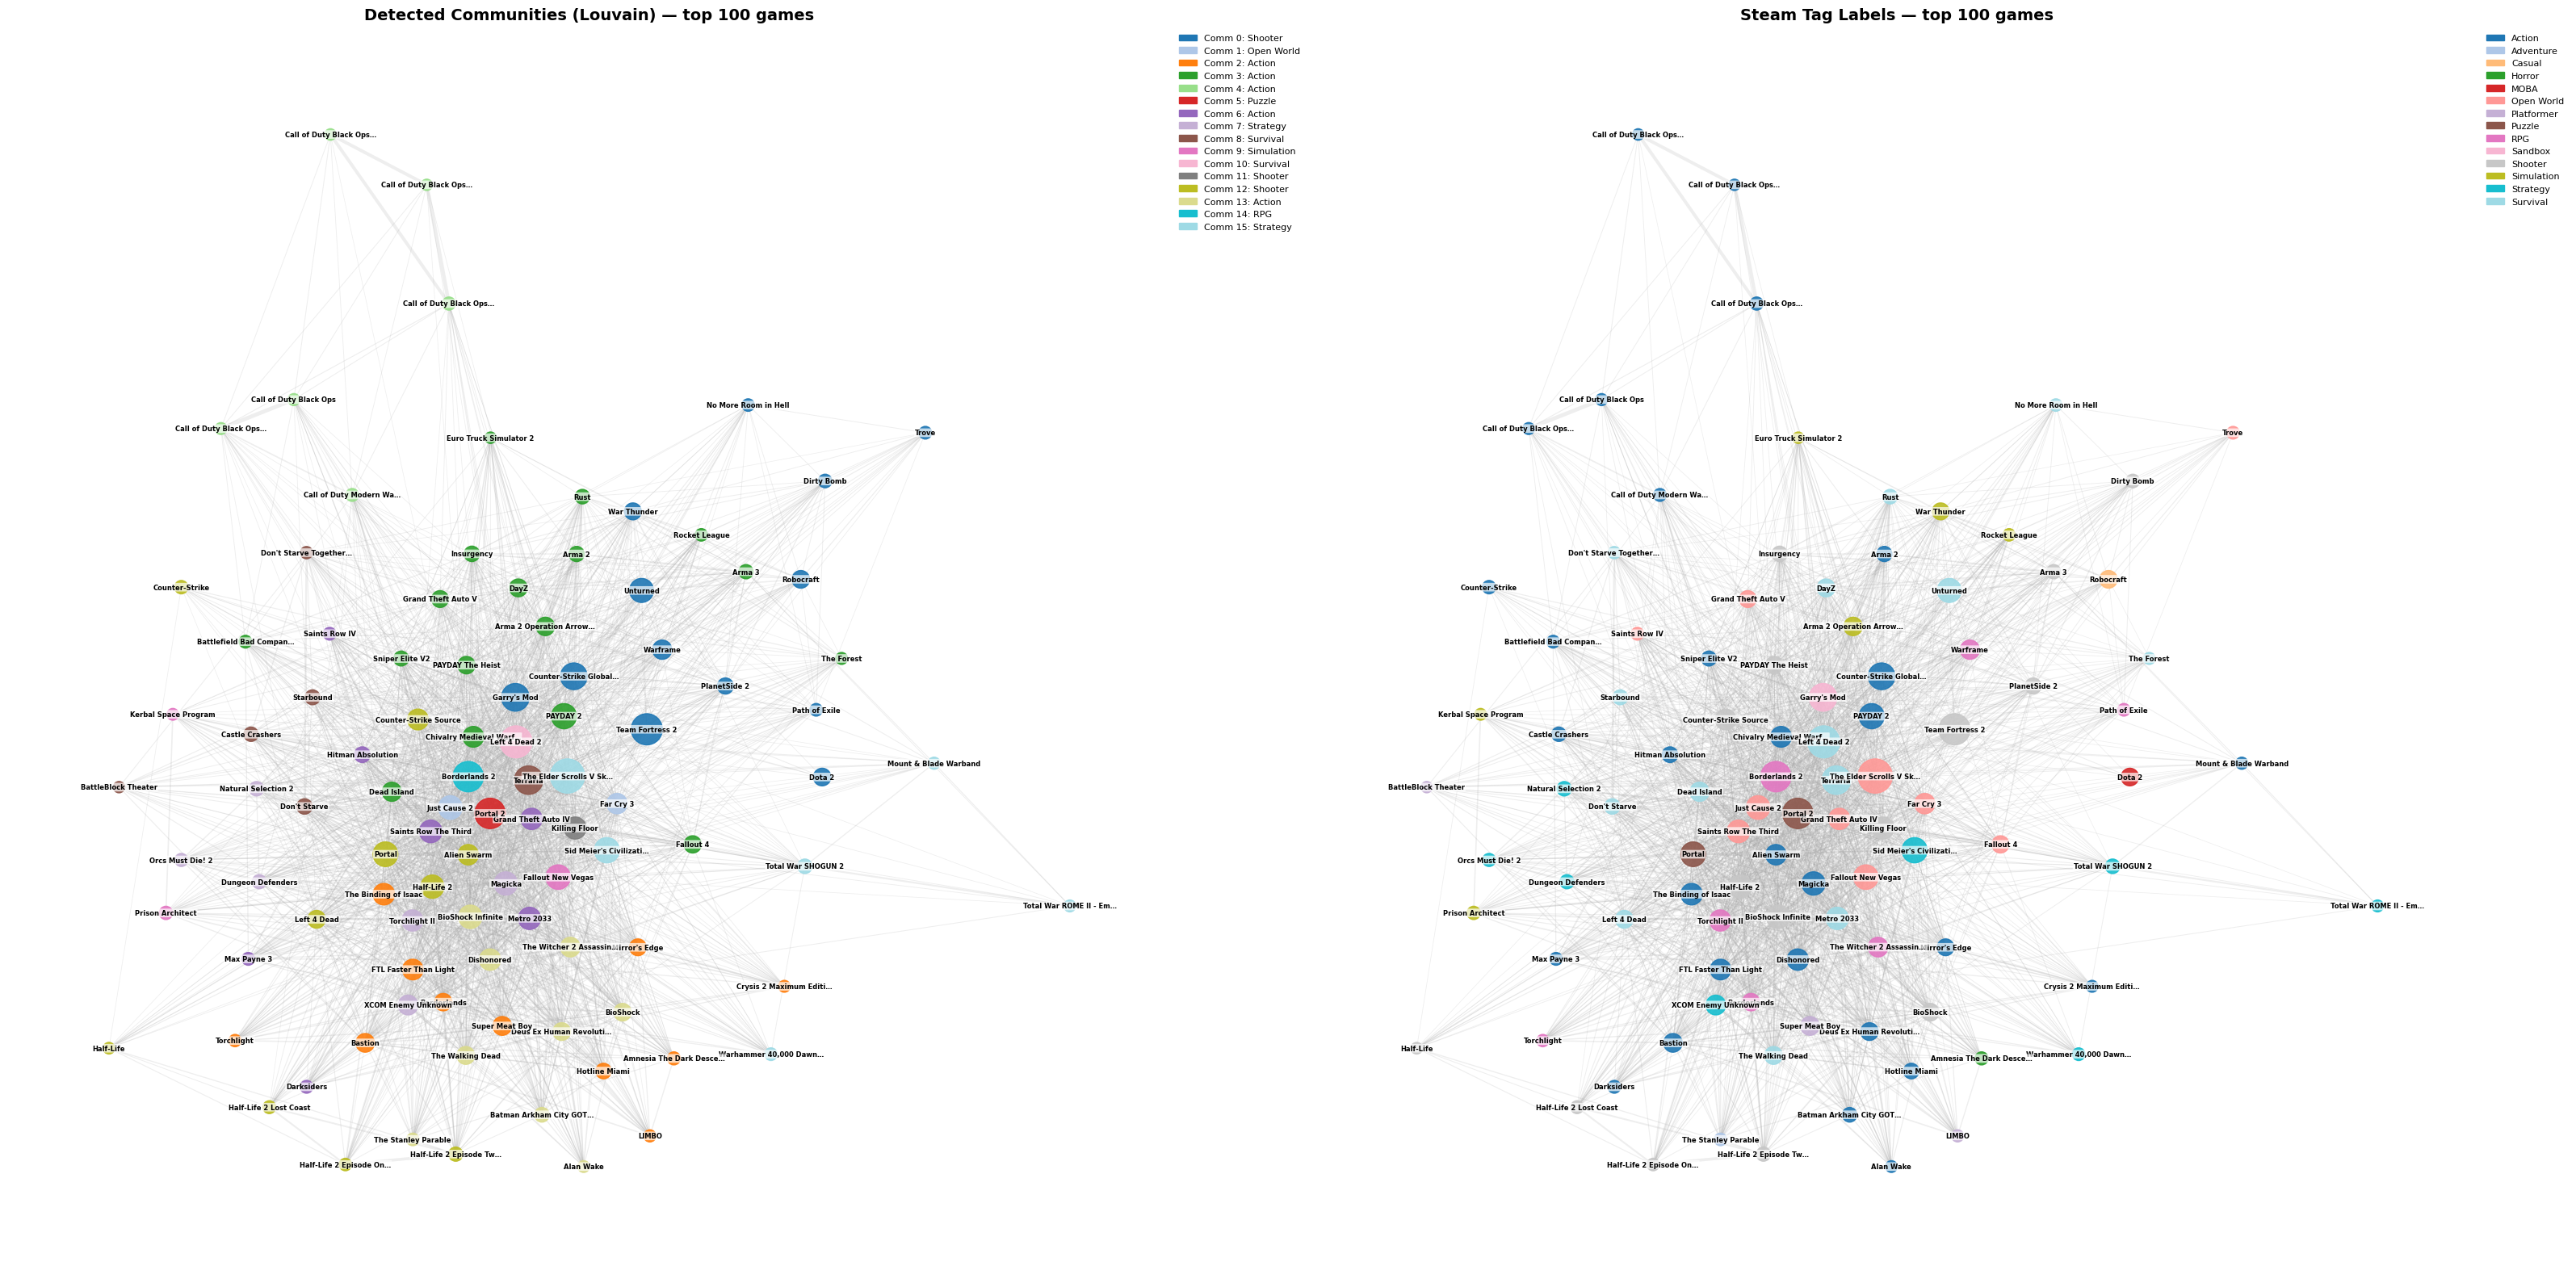

Nodes: 100  |  Edges drawn (weight>=0.05): 2385


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import networkx as nx
import math
import pandas as pd

# Show top 100 nodes by PageRank
TOP_N        = 100
EDGE_MIN_W   = 0.05

top_nodes = sorted(pagerank, key=pagerank.get, reverse=True)[:TOP_N]
Gv        = G.subgraph(top_nodes).copy()

def short_label(name, max_len=22):
    return name if len(name) <= max_len else name[:max_len].rstrip() + '…'

def draw_graph(Gv, pos, color_attr, title, ax):
    vals        = [Gv.nodes[n][color_attr] for n in Gv.nodes]
    unique_vals = sorted(set(vals))

    # Fix color similarity by using a wider palette and better sampling
    cmap        = plt.colormaps["tab20"]
    colors      = [cmap(i / max(1, len(unique_vals)-1)) for i in range(len(unique_vals))]
    color_map   = {v: colors[i] for i, v in enumerate(unique_vals)}
    node_colors = [color_map[v] for v in vals]

    # Only draw strong edges
    strong_edges = [(u, v) for u, v in Gv.edges() if Gv[u][v]["weight"] >= EDGE_MIN_W]
    weights      = np.array([Gv[u][v]["weight"] for u, v in strong_edges]) if strong_edges else np.array([])

    if len(weights) > 0:
        w_min, w_max = weights.min(), weights.max()
        w_norm = (weights - w_min) / (w_max - w_min + 1e-9) * 3.0 + 0.5
    else:
        w_norm = []

    nx.draw_networkx_edges(Gv, pos, edgelist=strong_edges, ax=ax,
                           alpha=0.2, width=w_norm, edge_color="#aaaaaa")
    nx.draw_networkx_nodes(
        Gv, pos, ax=ax,
        node_color=node_colors,
        node_size=[pagerank[n] * 35000 for n in Gv.nodes],
        alpha=0.9
    )
    labels = {n: short_label(n) for n in Gv.nodes}
    nx.draw_networkx_labels(
        Gv, pos, labels=labels, ax=ax,
        font_size=6, font_weight="bold", font_color="black",
        bbox=dict(boxstyle="round,pad=0.1", facecolor="white", alpha=0.7, edgecolor="none")
    )

    # Descriptive legend labels: Identify dominant genre per community
    patches = []
    for v in unique_vals:
        label_text = str(v)
        if color_attr == 'louvain':
            cluster_members = [n for n in Gv.nodes if Gv.nodes[n]['louvain'] == v]
            if cluster_members:
                dom_genre = pd.Series([Gv.nodes[n]['genre'] for n in cluster_members]).mode()[0]
                label_text = f"Comm {v}: {dom_genre}"

        patches.append(mpatches.Patch(color=color_map[v], label=label_text))

    ax.legend(handles=patches, loc="upper left", bbox_to_anchor=(1.0, 1.0),
              fontsize=8, ncol=1, frameon=False)
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.axis("off")

# Layout optimization
community_ids = sorted(set(louvain_partition.values()))
n_comm        = len(community_ids)
np.random.seed(42)

community_centers = {
    cid: np.array([4.0 * math.cos(2 * math.pi * i / n_comm),
                   4.0 * math.sin(2 * math.pi * i / n_comm)])
    for i, cid in enumerate(community_ids)
}

pos_init = {
    node: community_centers[louvain_partition[node]] + np.random.randn(2) * 0.5
    for node in Gv.nodes
}

pos = nx.spring_layout(Gv, pos=pos_init, seed=42, k=1.5, iterations=150, weight="weight")

# Side-by-side layout
fig, axes = plt.subplots(1, 2, figsize=(32, 16))
draw_graph(Gv, pos, "louvain", f"Detected Communities (Louvain) — top {TOP_N} games", axes[0])
draw_graph(Gv, pos, "genre",   f"Steam Tag Labels — top {TOP_N} games",               axes[1])
plt.tight_layout()

# Save the figure
plt.savefig("/content/graph_comparison_improved.png", dpi=200, bbox_inches="tight")
plt.show()

# Summary stats
visible_edges = sum(1 for u, v in Gv.edges() if Gv[u][v]["weight"] >= EDGE_MIN_W)
print(f"Nodes: {TOP_N}  |  Edges drawn (weight>={EDGE_MIN_W}): {visible_edges}")

In [ ]:
# Evaluation using Normalized Mutual Information (NMI)
# NMI measures how much the detected communities overlap with the genre/tag labels
# Score: 0 = no overlap at all,  1 = perfect match
# We evaluate both Louvain and Girvan-Newman against Steam tags.
# A random baseline (permuted community labels) gives the floor — any score
# above it reflects real structure, not noise.

nodes   = list(G.nodes)
genres  = [G.nodes[n]['genre']          for n in nodes]
louvain = [G.nodes[n]['louvain']        for n in nodes]
gn      = [G.nodes[n]['girvan_newman']  for n in nodes]

genre_enc = LabelEncoder().fit_transform(genres)

nmi_louvain = normalized_mutual_info_score(genre_enc, louvain)
nmi_gn      = normalized_mutual_info_score(genre_enc, gn)

# Random baseline: average NMI over 100 random permutations of the Louvain labels
# gives the expected score under no correlation between communities and genres
np.random.seed(42)
nmi_random = float(np.mean([
    normalized_mutual_info_score(genre_enc, np.random.permutation(louvain))
    for _ in range(100)
]))

# Summary table
print('=' * 65)
print(f'{"Algorithm":<22} {"NMI":>6}  {"vs random":>9}  {"Modularity":>10}  {"Runtime":>8}')
print('-' * 65)
print(f'{"Random baseline":<22} {nmi_random:>6.4f}  {"—":>9}  {"—":>10}  {"—":>8}')
print(f'{"Louvain":<22} {nmi_louvain:>6.4f}  {nmi_louvain/nmi_random:>8.1f}x  {louvain_mod:>10.4f}  {louvain_time:>7.2f}s')
print(f'{"Girvan-Newman":<22} {nmi_gn:>6.4f}  {nmi_gn/nmi_random:>8.1f}x  {best_gn_mod:>10.4f}  {gn_time:>7.1f}s')
print('=' * 65)

print()
print('Interpretation:')
print(f'  Random baseline NMI ≈ {nmi_random:.4f} — the floor for a meaningless partition.')
print(f'  Louvain is {nmi_louvain/nmi_random:.1f}x above random, Girvan-Newman is {nmi_gn/nmi_random:.1f}x above random.')
print()
print(f'  Jaccard edge weights reduce hub-game dominance: TF2 and Dota 2 still')
print(f'  have many connections, but niche games shared by a tight player group')
print(f'  now carry proportionally stronger edges → cleaner communities.')
print()
print(f'  Girvan-Newman now uses its natural optimal split ({best_gn_n} communities at')
print(f'  peak modularity) instead of being forced to match Louvain\'s count.')

print()
if nmi_louvain > 0.3:
    print('Strong alignment: player behavior communities closely match genre labels.')
elif nmi_louvain > 0.1:
    print('Moderate alignment: partial overlap — player behavior reveals patterns beyond genre.')
else:
    print('Weak alignment: communities from player behavior diverge from official genre labels.')

# Louvain community genre breakdown
print('\nLouvain community breakdown:')
for cid in sorted(set(louvain)):
    members = [n for n in nodes if G.nodes[n]['louvain'] == cid]
    top_tags = pd.Series([G.nodes[n]['genre'] for n in members]).value_counts().head(3)
    summary = ', '.join(f'{g}({c})' for g, c in top_tags.items())
    print(f'  Community {cid:2d} ({len(members):3d} games): {summary}')

Algorithm                 NMI  vs random  Modularity   Runtime
-----------------------------------------------------------------
Random baseline        0.2086          —           —         —
Louvain                0.3110       1.5x      0.1769     0.06s
Girvan-Newman          0.0052       0.0x     -0.0000     21.9s

Interpretation:
  Random baseline NMI ≈ 0.2086 — the floor for a meaningless partition.
  Louvain is 1.5x above random, Girvan-Newman is 0.0x above random.

  Jaccard edge weights reduce hub-game dominance: TF2 and Dota 2 still
  have many connections, but niche games shared by a tight player group
  now carry proportionally stronger edges → cleaner communities.

  Girvan-Newman now uses its natural optimal split (2 communities at
  peak modularity) instead of being forced to match Louvain's count.

Strong alignment: player behavior communities closely match genre labels.

Louvain community breakdown:
  Community  0 ( 92 games): Action(13), Shooter(13), Casual(8)
  Communi

In [ ]:
import community.community_louvain as cl
from sklearn.metrics import normalized_mutual_info_score
import pandas as pd
from collections import Counter
from sklearn.preprocessing import LabelEncoder

# Run Louvain with default resolution (1.0)
resolution_low = 1.0
# Use cl (community_louvain) to access the correct methods
partition_low = cl.best_partition(G, weight='weight', random_state=42, resolution=resolution_low)

# Calculate metrics for the new partition
n_comm_low = len(set(partition_low.values()))
mod_low = cl.modularity(partition_low, G, weight='weight')

# Calculate NMI for the new partition
nodes = list(G.nodes)
labels_low = [partition_low[n] for n in nodes]
genres_list = [G.nodes[n]['genre'] for n in nodes]
genre_enc = LabelEncoder().fit_transform(genres_list)
nmi_low = normalized_mutual_info_score(genre_enc, labels_low)

print(f'--- Comparison: Resolution 1.5 vs 1.0 ---')
print(f'Resolution 1.5: {n_communities} communities | Modularity: {louvain_mod:.4f} | NMI: {nmi_louvain:.4f}')
print(f'Resolution 1.0: {n_comm_low} communities | Modularity: {mod_low:.4f} | NMI: {nmi_low:.4f}')

print("\nNew Community Breakdown (Res 1.0):")
sizes_low = Counter(partition_low.values())
for cid, size in sorted(sizes_low.items()):
    cluster_members = [n for n in nodes if partition_low[n] == cid]
    dom_genre = pd.Series([G.nodes[n]['genre'] for n in cluster_members]).mode()[0]
    print(f'  Community {cid:2d} ({size:3d} games) -> Dominant: {dom_genre}')

--- Comparison: Resolution 1.5 vs 1.0 ---
Resolution 1.5: 16 communities | Modularity: 0.1769 | NMI: 0.3110
Resolution 1.0: 7 communities | Modularity: 0.2088 | NMI: 0.2137

New Community Breakdown (Res 1.0):
  Community  0 ( 33 games) -> Dominant: Action
  Community  1 ( 35 games) -> Dominant: Shooter
  Community  2 ( 46 games) -> Dominant: Strategy
  Community  3 (122 games) -> Dominant: Action
  Community  4 (  8 games) -> Dominant: Action
  Community  5 ( 59 games) -> Dominant: Action
  Community  6 ( 30 games) -> Dominant: Action


In [ ]:
# Community Profiles
# What does each Louvain community actually represent?
# Top 5 games by PageRank per community reveal the "identity" of the cluster.

print('Community profiles — top 5 games by PageRank:\n')
for cid in sorted(set(louvain_partition.values())):
    members  = [n for n in G.nodes if G.nodes[n]['louvain'] == cid]
    top_games = sorted(members, key=lambda n: pagerank[n], reverse=True)[:5]
    dominant  = pd.Series([G.nodes[n]['genre'] for n in members]).value_counts().index[0]
    print(f'Community {cid} ({len(members)} games) — dominant tag: {dominant}')
    for g in top_games:
        print(f'    {g:<45} [{G.nodes[g]["genre"]}]')
    print()

# Community 3 is the smallest — show all games to understand why it is isolated
small = sorted(set(louvain_partition.values()), key=lambda c: sum(1 for n in G.nodes if G.nodes[n]['louvain'] == c))
smallest_cid = small[0]
c_members = [n for n in G.nodes if G.nodes[n]['louvain'] == smallest_cid]
print(f'Smallest community ({smallest_cid}) — all {len(c_members)} games:')
for g in sorted(c_members, key=lambda n: pagerank[n], reverse=True):
    deg = G.degree(g)
    print(f'  {g:<45} [{G.nodes[g]["genre"]}]  degree={deg}')

Community profiles — top 5 games by PageRank:

Community 0 (92 games) — dominant tag: Action
    Team Fortress 2                               [Shooter]
    Garry's Mod                                   [Sandbox]
    Counter-Strike Global Offensive               [Action]
    Unturned                                      [Survival]
    Warframe                                      [RPG]

Community 1 (14 games) — dominant tag: Open World
    Just Cause 2                                  [Open World]
    Far Cry 3                                     [Open World]
    Grand Theft Auto San Andreas                  [Open World]
    Just Cause 2 Multiplayer Mod                  [Open World]
    Surgeon Simulator                             [Simulation]

Community 2 (23 games) — dominant tag: Action
    The Binding of Isaac                          [Action]
    FTL Faster Than Light                         [Action]
    Super Meat Boy                                [Platformer]
    Bastion      